# 02 — Mesh bridge round trip

`physicsnemo.mesh` handles strictly simplicial meshes; Kratos meshes generally are not.
This notebook tessellates a mixed hexahedron + tetrahedron mesh, checks volume
conservation, builds a `DomainMesh` with a named boundary, and shows that nodal
predictions scatter back **exactly** onto the original Kratos nodes.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo   # optional runtime dependencies of the application
> ```
>
> Everything below runs on CPU in a few seconds; outputs are written to `./output/`.

In [1]:
from pathlib import Path

import numpy
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication.bridges.mesh_bridge import domain_mesh_builder

Path("output").mkdir(exist_ok=True)
from KratosMultiphysics import pyvista_utilities as pv_utils
import pyvista as pv

## A mixed mesh with a boundary sub-model-part

One unit hexahedron plus a tetrahedron glued to its `x=1` face; the `z=0` face is
registered as the boundary sub-model-part `Bottom` (a quad surface condition).

In [2]:
model = Kratos.Model()
model_part = model.CreateModelPart("Main")
model_part.AddNodalSolutionStepVariable(Kratos.PRESSURE)
props = model_part.CreateNewProperties(1)

coordinates = [
    (0.0, 0.0, 0.0), (1.0, 0.0, 0.0), (1.0, 1.0, 0.0), (0.0, 1.0, 0.0),
    (0.0, 0.0, 1.0), (1.0, 0.0, 1.0), (1.0, 1.0, 1.0), (0.0, 1.0, 1.0),
    (2.0, 0.0, 0.0),
]
for i, xyz in enumerate(coordinates):
    node = model_part.CreateNewNode(i + 1, *xyz)
    node.SetSolutionStepValue(Kratos.PRESSURE, float(node.Id))
model_part.CreateNewElement("Element3D8N", 1, [1, 2, 3, 4, 5, 6, 7, 8], props)
model_part.CreateNewElement("Element3D4N", 2, [2, 9, 3, 6], props)

bottom = model_part.CreateSubModelPart("Bottom")
bottom.AddNodes([1, 2, 3, 4])
model_part.CreateNewCondition("SurfaceCondition3D4N", 1, [1, 2, 3, 4], props)
bottom.AddConditions([1])

## Tessellation with provenance

`BuildProvenance` is pure numpy (no ML dependency): the hexahedron becomes 6
tetrahedra, the tetrahedron stays itself, and every simplex point/cell remembers the
Kratos entity it came from.

In [3]:
provenance = domain_mesh_builder.BuildProvenance(model_part)
print(f"{provenance.number_of_points} simplex points, {provenance.number_of_cells} simplex cells")
print("cell provenance (source element id, sub-cell):")
print(provenance.cell_provenance)

kratos_volume = sum(element.GetGeometry().Volume() for element in model_part.Elements)
simplex_volume = provenance.ComputeSimplexMeasures().sum()
print(f"Kratos volume = {kratos_volume:.12f}, tessellated volume = {simplex_volume:.12f}")
assert abs(kratos_volume - simplex_volume) < 1e-12

9 simplex points, 7 simplex cells
cell provenance (source element id, sub-cell):
[[1 0]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]
 [2 0]]
Kratos volume = 1.166666666667, tessellated volume = 1.166666666667


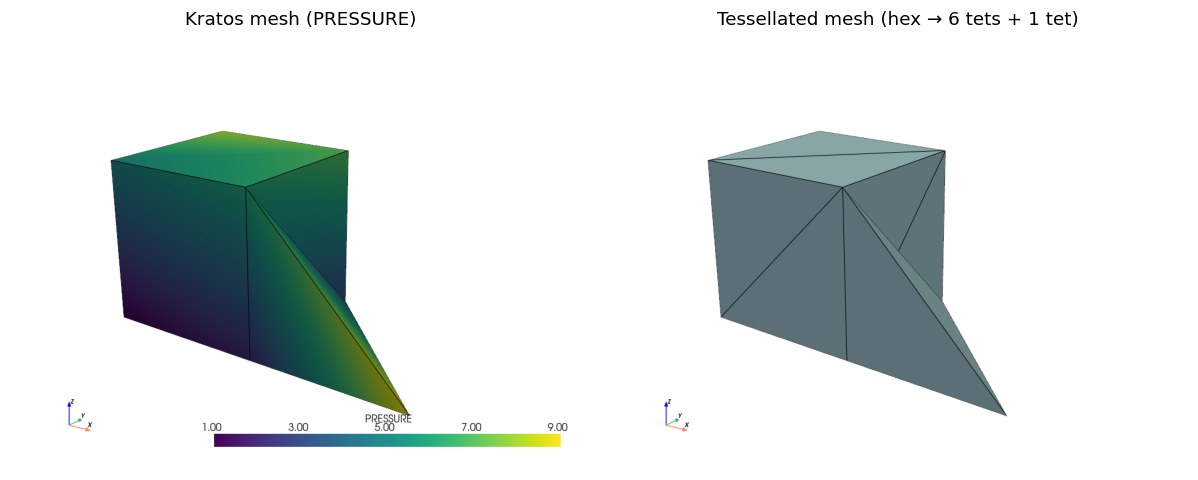

In [4]:
# Two meshes are "considered" here: the original Kratos mesh (hex + tet
# elements) and the tessellated simplicial mesh BuildProvenance produced.
# Both are rendered with the core pyvista bridge (KratosMultiphysics.pyvista_utilities).
kratos_img = pv_utils.ScreenshotModelPart(
    model_part, filename=None, name=Kratos.PRESSURE, cmap="viridis")

# The tessellated (simplex) mesh is physicsnemo.mesh's internal representation,
# not a Kratos ModelPart, so it is wrapped into a pyvista.UnstructuredGrid by
# hand, reusing the same VTK tetra cell type pyvista_utilities uses internally.
tetraType = pv_utils.GEOMETRY_TYPE_TO_VTK_CELL_TYPE[Kratos.GeometryData.KratosGeometryType.Kratos_Tetrahedra3D4]
tessCells = provenance.simplex_cells
cells = numpy.hstack(
    [numpy.full((len(tessCells), 1), 4, dtype=numpy.int64), tessCells.astype(numpy.int64)]).ravel()
cellTypes = numpy.full(len(tessCells), tetraType, dtype=numpy.uint8)
tessGrid = pv.UnstructuredGrid(cells, cellTypes, provenance.simplex_points)

tessPlotter = pv.Plotter(off_screen=True)
tessPlotter.add_mesh(tessGrid, show_edges=True, color="lightblue")
tessPlotter.add_axes()
tessPlotter.camera.elevation = -15
tessPlotter.camera.azimuth = -100
tess_img = tessPlotter.screenshot(None)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(kratos_img); axes[0].set_title("Kratos mesh (PRESSURE)"); axes[0].axis("off")
axes[1].imshow(tess_img); axes[1].set_title("Tessellated mesh (hex \u2192 6 tets + 1 tet)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("output/tessellation.png", dpi=120, bbox_inches="tight")
plt.show()

## DomainMesh with a named boundary

Sub-model-parts holding conditions map onto `physicsnemo.mesh.DomainMesh` named
boundaries. Requires `physicsnemo` (imported lazily by the builder).

In [5]:
domain_mesh, provenance_maps = domain_mesh_builder.BuildDomainMesh(
    model_part,
    field_specs=[(Kratos.PRESSURE, "node_historical")],
    boundary_sub_model_part_names=["Bottom"])
print("boundaries:", list(domain_mesh.boundaries.keys()))
print("interior PRESSURE:", tuple(domain_mesh.interior.point_data["PRESSURE"].shape))
print("Bottom PRESSURE:  ", tuple(domain_mesh.boundaries["Bottom"].point_data["PRESSURE"].shape))

boundaries: ['Bottom']
interior PRESSURE: (9,)
Bottom PRESSURE:   (4,)


## Exact nodal round trip

Corner-only tessellation makes node ↔ simplex-point a bijection, so scattering a nodal
prediction back is exact — here demonstrated with an identity "prediction".

In [6]:
node_ids = [node.Id for node in model_part.Nodes]
original = numpy.array([node.GetSolutionStepValue(Kratos.PRESSURE) for node in model_part.Nodes])

point_field = provenance.GatherNodalField(node_ids, original)   # Kratos -> simplex points
domain_mesh_builder.ScatterFieldBack(                            # simplex points -> Kratos
    provenance, point_field, model_part, Kratos.PRESSURE, "node_historical")

recovered = numpy.array([node.GetSolutionStepValue(Kratos.PRESSURE) for node in model_part.Nodes])
print("bit-exact recovery:", numpy.array_equal(original, recovered))

bit-exact recovery: True


## Saving in physicsnemo's native format

`SaveMesh`/`LoadMesh` wrap the memory-mapped on-disk format (supports lazy/partial
loading of large meshes).

In [7]:
domain_mesh_builder.SaveMesh(domain_mesh.interior, "output/saved_mesh")
loaded = domain_mesh_builder.LoadMesh("output/saved_mesh")
print("reloaded:", tuple(loaded.points.shape), "with fields", list(loaded.point_data.keys()))

reloaded: (9, 3) with fields ['PRESSURE']
